## Lab 1: $k$-NN
**Exercise 1**: Algorithmic implementation

## Lab 2  : Classification
**Models**: Logistic Regression, Linear Discriminant Analysis (LDA), Quadratic Discriminant Analysis (QDA) <br>
**ROC** curve and graphical representations


   Year   Lag1   Lag2   Lag3   Lag4   Lag5  Volume  Today Direction
0  2001  0.381 -0.192 -2.624 -1.055  5.010  1.1913  0.959        Up
1  2001  0.959  0.381 -0.192 -2.624 -1.055  1.2965  1.032        Up
2  2001  1.032  0.959  0.381 -0.192 -2.624  1.4112 -0.623      Down
3  2001 -0.623  1.032  0.959  0.381 -0.192  1.2760  0.614        Up
4  2001  0.614 -0.623  1.032  0.959  0.381  1.2057  0.213        Up

 Logistic Regression Summary:
                 Generalized Linear Model Regression Results                  
Dep. Variable:          Direction_bin   No. Observations:                  998
Model:                            GLM   Df Residuals:                      994
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -690.57
Date:                Tue, 01 Jul 2025   Deviance:                       1381.1
Time:   

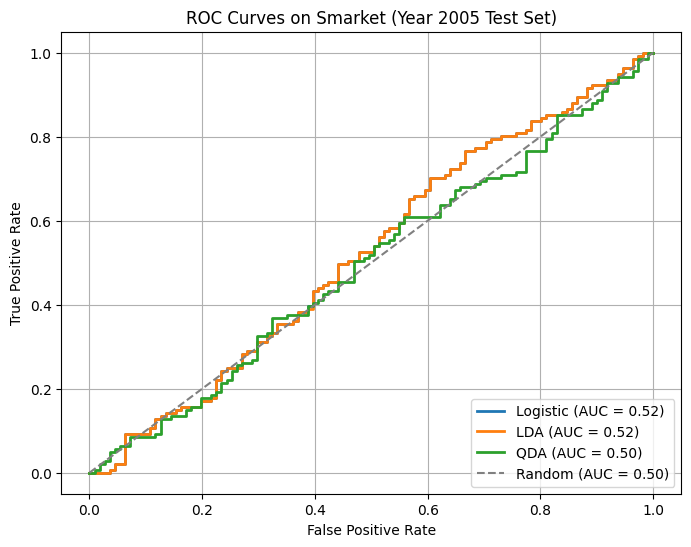

In [2]:
# 0) Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Statsmodels for logistic regression
import statsmodels.api as sm
import statsmodels.formula.api as smf

# scikit-learn for LDA, QDA, and ROC
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Load Smarket from ISLP
from ISLP import load_data

# 1) Load and inspect data
Smarket = load_data('Smarket')
print(Smarket.head())

# 2) Prepare data
# Add a binary 0/1 outcome for 'Direction'
Smarket['Direction_bin'] = (Smarket['Direction'] == 'Up').astype(int)

# 3) Train/Test split: train = Year < 2005, test = Year == 2005
train = Smarket[Smarket.Year < 2005]
test  = Smarket[Smarket.Year == 2005]

X_train = train[['Lag1', 'Lag2', 'Volume']]
X_test  = test [['Lag1', 'Lag2', 'Volume']]
y_train = train['Direction_bin']
y_test  = test ['Direction_bin']


# 4) Logistic Regression (statsmodels)
logit_mod = smf.glm(
    formula='Direction_bin ~ Lag1 + Lag2 + Volume',
    data=train,
    family=sm.families.Binomial()).fit()

logit_proba = logit_mod.predict(test)

print("\n Logistic Regression Summary:")
print(logit_mod.summary())

# 5) LDA (scikit-learn)
lda = LinearDiscriminantAnalysis(store_covariance=True)
lda.fit(X_train, y_train)
lda_proba = lda.predict_proba(X_test)[:, 1]

# 6) QDA (scikit-learn)
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
qda_proba = qda.predict_proba(X_test)[:, 1]

# 7) Confusion Matrices
for name, proba in zip(['Logistic', 'LDA', 'QDA'],
                       [logit_proba, lda_proba, qda_proba]):
    y_pred = (proba > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name} Confusion Matrix (threshold = 0.5):")
    print(pd.DataFrame(
        cm,
        index=['Actual Down', 'Actual Up'],
        columns=['Pred Down', 'Pred Up']
    ))

# 8) ROC Curves & AUC
fpr_log, tpr_log, _ = roc_curve(y_test, logit_proba)
auc_log = auc(fpr_log, tpr_log)

fpr_lda, tpr_lda, _ = roc_curve(y_test, lda_proba)
auc_lda = auc(fpr_lda, tpr_lda)

fpr_qda, tpr_qda, _ = roc_curve(y_test, qda_proba)
auc_qda = auc(fpr_qda, tpr_qda)

# 9) Plot ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, lw=2, label=f"Logistic (AUC = {auc_log:.2f})")
plt.plot(fpr_lda, tpr_lda, lw=2, label=f"LDA (AUC = {auc_lda:.2f})")
plt.plot(fpr_qda, tpr_qda, lw=2, label=f"QDA (AUC = {auc_qda:.2f})")
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Smarket (Year 2005 Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Lab 3 : Cross-Validation and Bootstrap

In [ ]:
# Standard Libraries
import numpy as np
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
from sklearn.model_selection import train_test_split

# Re-sampling Libraries
from functools import partial
from sklearn.model_selection import (cross_validate,
                                     KFold,
                                     ShuffleSplit,
                                     LeaveOneOut)
from sklearn.base import clone
from ISLP.models import sklearn_sm

import matplotlib.pyplot as plt

**Cross Validation**

*Leave One Out* Cross Validation

In [4]:
#LOOCV
Auto = load_data('Auto')

hp_model = sklearn_sm(sm.OLS,
                      MS(['horsepower']))
X, Y = Auto.drop(columns=['mpg']), Auto['mpg']
cv_results = cross_validate(hp_model,
                            X,
                            Y,
                            cv=Auto.shape[0])
cv_err = np.mean(cv_results['test_score'])
cv_err

24.23151351792922

In [5]:
#LOOCV for finding optimal d
cv_error = np.zeros(5)
H = np.array(Auto['horsepower'])
M = sklearn_sm(sm.OLS)
for i, d in enumerate(range(1,6)):
    X = np.power.outer(H, np.arange(d+1))
    M_CV = cross_validate(M,
                          X,
                          Y,
                          cv=Auto.shape[0])
    cv_error[i] = np.mean(M_CV['test_score'])
cv_error

array([24.23151352, 19.24821312, 19.33498406, 19.42443029, 19.03320648])

*K-Fold* Cross Validation

Sepcial Case $d=1$

In [6]:
hp_model = sklearn_sm(sm.OLS, MS(['horsepower']))
X, Y = Auto.drop(columns=['mpg']), Auto['mpg']

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(hp_model,
                            X,
                            Y,
                            cv=cv)

cv_err = np.mean(cv_results['test_score'])
print(cv_err)

24.219824054860858


Gereal case $d\in[10]$

In [7]:
cv_error = np.zeros(5)
H = np.array(Auto['horsepower'])
M = sklearn_sm(sm.OLS)
cv = KFold(n_splits=10,
           shuffle=True,
           random_state=0) # use same splits for each degree

for i, d in enumerate(range(1,6)):
    X = np.power.outer(H, np.arange(d+1))
    M_CV = cross_validate(M,
                          X,
                          Y,
                          cv=cv)
    cv_error[i] = np.mean(M_CV['test_score'])
cv_error

array([24.20766449, 19.18533142, 19.27626666, 19.47848403, 19.13720065])

Different Implementation

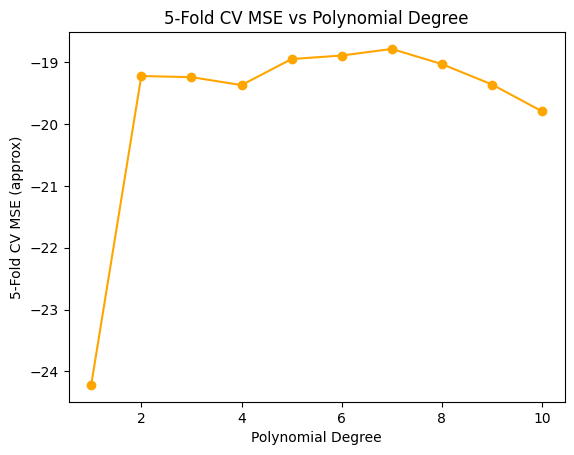

In [8]:
Auto = load_data('Auto')

# Pass only the relevant feature column as DataFrame
X = Auto[['horsepower']]
Y = Auto['mpg']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mpe_kfold = np.zeros(10)
for n in range(1, 11):
    model = sklearn_sm(sm.OLS, MS([poly('horsepower', n)]))
    cv_results = cross_validate(model, X, Y, cv=kf)
    mpe_kfold[n-1] = -np.mean(cv_results['test_score'])

plt.plot(range(1, 11), mpe_kfold, marker='o', color='orange')
plt.xlabel('Polynomial Degree')
plt.ylabel('5-Fold CV MSE (approx)')
plt.title('5-Fold CV MSE vs Polynomial Degree')
plt.show()

**Bootstrap**

In [ ]:
# Libraries
import numpy as np
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
                         summarize ,
                         poly)
from sklearn.model_selection import train_test_split

from functools import partial
from sklearn.model_selection import (cross_validate,
                                     KFold,
                                     ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

Εκτίμηση ακριβείας στατιστικής μέτρισης
$$
\alpha = \frac{\sigma_Y^2 - \text{Cov}(X,Y)}{\sigma_X^2 + \sigma_Y^2 - 2 \cdot \text{Cov}(X,Y)}
$$

όπου:

- $\sigma_X^2$ η διασπορά της X  
- $\sigma_Y^2$ η διασπορά της Y  
- $\text{Cov}(X,Y)$ η συνδιακύμναση των X και Y

In [45]:
# Portfolio Alpha Calculation
Portfolio = load_data('Portfolio')
Auto = load_data('Auto')
def alpha_func(D, idx):
    cov_ = np.cov(D[['X','Y']].loc[idx], rowvar=False)
    return (( cov_ [1,1] - cov_ [0 ,1]) /
            (cov_ [0 ,0]+ cov_ [1 ,1] -2* cov_ [0 ,1]))

In [33]:
#Bootstrap sample

rng = np.random.default_rng (0)
alpha_func(Portfolio ,
           rng.choice (100,100,replace=True))

0.6074452469619004

Εκτίμηση Ακριβείας Γραμμικού Μοντέλου

In [47]:
# Bootstrap for Linear Regression
def boot_OLS(model_matrix , response , D, idx):
    D_ = D.iloc[idx]
    Y_ = D_[response]
    X_ = clone(model_matrix).fit_transform(D_)
    return sm.OLS(Y_ , X_).fit().params

hp_func = partial(boot_OLS , MS(['horsepower']), 'mpg')

In [48]:
rng = np.random.default_rng (0)
np.array ([ hp_func(Auto ,
                    rng.choice (392,
                                392,
                                replace=True)) for _ in range (10) ])

array([[39.88064456, -0.1567849 ],
       [38.73298691, -0.14699495],
       [38.31734657, -0.14442683],
       [39.91446826, -0.15782234],
       [39.43349349, -0.15072702],
       [40.36629857, -0.15912217],
       [39.62334517, -0.15449117],
       [39.0580588 , -0.14952908],
       [38.66688437, -0.14521037],
       [39.64280792, -0.15555698]])

In [59]:
def boot_SE(func, D, n=None, B=1000, seed=0):
    rng = np.random.default_rng(seed)
    first_, second_ = 0, 0
    n = n or D.shape[0]
    for _ in range(B):
        idx = rng.choice(len(D), n, replace=True)
        value = func(D, idx)
        first_ += value
        second_ += value**2
    return np.sqrt(second_ / B - (first_ / B)**2)


In [60]:
hp_se = boot_SE(hp_func ,
                Auto ,
                B=1000 ,
                seed =10)
hp_se

intercept     0.848807
horsepower    0.007352
dtype: float64

## Lab 4 : Shrinkage Methods & Dimention Reduction Methods
**Ridge**, **Lasso**, **Elastic Net** Methods (for Regression)

In [10]:
# Load Basic Libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

In [11]:
#Lab Specifics
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
    (Stepwise,
     sklearn_selected,
     sklearn_selection_path)
from l0bnb import fit_path

In [12]:
#Set up
Hitters = load_data('Hitters')

Hitters = Hitters.dropna()

ms = MS(Hitters.columns.drop('Salary'))
X = ms.fit_transform(Hitters)

y = Hitters['Salary']

#Ridge1
ridge1 = skl.Ridge(alpha=10)
ridge1.fit(X, y)

print(f"Coefficients: {ridge1.coef_}")
print(f"Intercept: {ridge1.intercept_}")

b1 = ridge1.coef_

#Ridge2
ridge2 = skl.Ridge(alpha=1000)
ridge2.fit(X, y)

b2 = ridge2.coef_

#Multiple Trials
lambda_values = np.logspace(-2, 8, 40)

print(lambda_values)

ridge_all = []
for lam in lambda_values:
    ridge_temp = skl.Ridge(alpha=lam)
    ridge_temp.fit(X, y)
    ridge_all.append(ridge_temp)

ridge1_coef = np.concatenate([[ridge1.intercept_], ridge1.coef_])
print(ridge1_coef)

B_list = []
for ridge_model in ridge_all:
    coef_with_intercept = np.concatenate([[ridge_model.intercept_], ridge_model.coef_])
    B_list.append(coef_with_intercept)

B = np.array(B_list).T

Coefficients: [   0.           -2.02407093    7.57776863    4.07288782   -2.32997661
   -0.90413497    6.19932263   -3.26353474   -0.17068612    0.10860835
   -0.20283355    1.4922412     0.81786908   -0.80976911   37.79015678
 -100.4845849     0.28368933    0.37342172   -3.21589478   -2.43318705]
Intercept: 157.6146169705413
[1.00000000e-02 1.80472177e-02 3.25702066e-02 5.87801607e-02
 1.06081836e-01 1.91448198e-01 3.45510729e-01 6.23550734e-01
 1.12533558e+00 2.03091762e+00 3.66524124e+00 6.61474064e+00
 1.19377664e+01 2.15443469e+01 3.88815518e+01 7.01703829e+01
 1.26638017e+02 2.28546386e+02 4.12462638e+02 7.44380301e+02
 1.34339933e+03 2.42446202e+03 4.37547938e+03 7.89652287e+03
 1.42510267e+04 2.57191381e+04 4.64158883e+04 8.37677640e+04
 1.51177507e+05 2.72833338e+05 4.92388263e+05 8.88623816e+05
 1.60371874e+06 2.89426612e+06 5.22334507e+06 9.42668455e+06
 1.70125428e+07 3.07029063e+07 5.54102033e+07 1.00000000e+08]
[ 1.57614617e+02  0.00000000e+00 -2.02407093e+00  7.57776863e

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# RIDGE REGRESSION (L2 penalty)
ridge = skl.Ridge(alpha=10)
ridge.fit(X, y)

# LASSO REGRESSION (L1 penalty)  
lasso = skl.Lasso(alpha=10)
lasso.fit(X, y)

# ELASTIC NET (L1 + L2 penalty)
elastic = skl.ElasticNet(alpha=10, l1_ratio=0.5)
elastic.fit(X, y)

# PARAMETER CONTROL:

# Ridge: only control alpha (regularization strength)
ridge_weak = skl.Ridge(alpha=0.1)      # less regularization
ridge_strong = skl.Ridge(alpha=100)    # more regularization

# Lasso: only control alpha (regularization strength)  
lasso_weak = skl.Lasso(alpha=0.1)      # less regularization
lasso_strong = skl.Lasso(alpha=100)    # more regularization

# Elastic Net: control both alpha and l1_ratio
# alpha = regularization strength
# l1_ratio = mix between L1 and L2 (0=Ridge, 1=Lasso)

elastic_ridge_like = skl.ElasticNet(alpha=10, l1_ratio=0.1)    # mostly L2
elastic_balanced = skl.ElasticNet(alpha=10, l1_ratio=0.5)      # equal L1+L2  
elastic_lasso_like = skl.ElasticNet(alpha=10, l1_ratio=0.9)    # mostly L1

# CROSS-VALIDATION (finds best parameters automatically)
ridge_cv = skl.RidgeCV(alphas=[0.1, 1, 10, 100])
lasso_cv = skl.LassoCV(alphas=[0.1, 1, 10, 100], max_iter=10000)
elastic_cv = skl.ElasticNetCV(alphas=[0.1, 1, 10, 100], l1_ratio=[0.1, 0.5, 0.9], max_iter=10000)


# FIT AND GET BEST PARAMETERS
ridge_cv.fit(X, y)
print(f"Best Ridge alpha: {ridge_cv.alpha_}")

lasso_cv.fit(X, y) 
print(f"Best Lasso alpha: {lasso_cv.alpha_}")

elastic_cv.fit(X, y)
print(f"Best Elastic alpha: {elastic_cv.alpha_}, l1_ratio: {elastic_cv.l1_ratio_}")

Best Ridge alpha: 10.0
Best Lasso alpha: 100.0
Best Elastic alpha: 100.0, l1_ratio: 0.9


/home/andreaspanayi8/Documents/machine_learning_exercises /labs/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.066e+07, tolerance: 5.332e+03
  model = cd_fast.enet_coordinate_descent(
/home/andreaspanayi8/Documents/machine_learning_exercises /labs/.venv/lib64/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.166e+07, tolerance: 5.332e+03
  model = cd_fast.enet_coordinate_descent(


**PCA** Analysis

              cylinders  displacement  horsepower    weight  acceleration
cylinders      1.000000      0.950823    0.842983  0.897527     -0.504683
displacement   0.950823      1.000000    0.897257  0.932994     -0.543800
horsepower     0.842983      0.897257    1.000000  0.864538     -0.689196
weight         0.897527      0.932994    0.864538  1.000000     -0.416839
acceleration  -0.504683     -0.543800   -0.689196 -0.416839      1.000000
[[ 0.46871748  0.4824044   0.47384374  0.46179021 -0.3313787 ]
 [ 0.2234786   0.17862974 -0.11998855  0.34528638  0.8857363 ]
 [ 0.65869995  0.18764042 -0.62757104 -0.33449699 -0.15865624]
 [-0.27031946 -0.02124108 -0.59359925  0.70324388 -0.28207124]
 [-0.47265527  0.83649107 -0.12194007 -0.24715772  0.03038708]]


Text(0.5, 1.0, 'PCA: Scores plot')

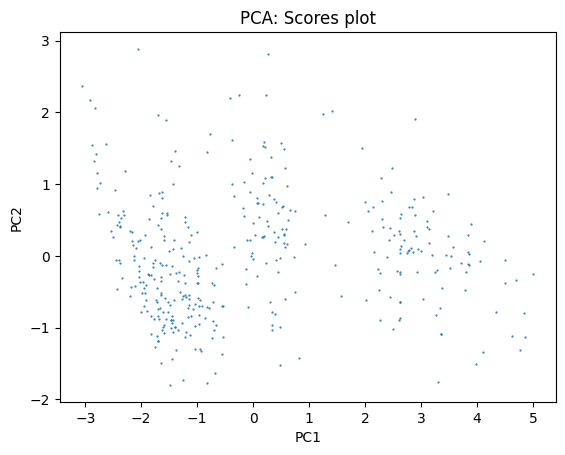

In [ ]:
Auto = load_data('Auto')

# Select columns 2 to 6 (Python indexing: columns 1 to 5)
X = Auto.iloc[:, 1:6]

# Correlation matrix
print(X.corr())

# Standardize and perform PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

# PCA components (loadings)
print(pca.components_)  # Equivalent to p1.pca$rotation

# First two principal components (loading vectors)
w1 = pca.components_[0]
w2 = pca.components_[1]

# Project the data onto the first two PCs (scores)
s1 = X_scaled @ w1
s2 = X_scaled @ w2

# Plot s2 vs s1 with point size 0.3
fig, ax = subplots()
ax.scatter(s1, s2, s=0.3)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA: Scores plot')

## Lab 5 : Splines

In [4]:
#Basic
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (summarize,
                         poly,
                         ModelSpec as MS)
from statsmodels.stats.anova import anova_lm

#Specific
from pygam import (s as s_gam,
                   l as l_gam,
                   f as f_gam,
                   LinearGAM,
                   LogisticGAM)
from ISLP.transforms import (BSpline,
                             NaturalSpline)
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,
                        degrees_of_freedom,
                        plot as plot_gam,
                        anova as anova_gam)

**Splines**

In [ ]:
# Load the Wage dataset (assuming load_data is a predefined function to import it)
Wage = load_data('Wage')

y = Wage['wage']
age = Wage['age']

# 1. Fit a B-spline basis on age with 3 internal knots at 25, 40, 60 (default degree=3)
bs_ = BSpline(internal_knots=[25,40,60], intercept=True).fit(age)

bs_age = bs_.transform(age)
print(bs_age.shape)

# 2. Using patsy-like formula syntax with ModelSpec (MS) to create the spline basis directly
bs_age = MS([bs('age', internal_knots=[25,40,60])])
Xbs = bs_age.fit_transform(Wage)

# Fit an OLS regression B-spline model
M = sm.OLS(y, Xbs).fit()

# 3. Same as above but with better naming
bs_age = MS([bs('age',
                internal_knots=[25,40,60],
                name='bs(age)')])

Xbs = bs_age.fit_transform(Wage)
M = sm.OLS(y, Xbs).fit()

# 4. Constructing B-splines by specifying degrees of freedom (df=6 here)
BSpline(df=6).fit(age)

# 5. Fitting a piecewise constant spline basis with df=3
bs_age0 = MS([bs('age',
                 df=3,
                 degree=0)]).fit(Wage)
Xbs0 = bs_age0.transform(Wage)

# 6. Natural spline basis with df=5
ns_age = MS([ns('age', df=5)]).fit(Wage)
M_ns = sm.OLS(y, ns_age.transform(Wage)).fit()

(3000, 7)


0        75.043154
1        70.476020
2       130.982177
3       154.685293
4        75.043154
           ...    
2995    154.685293
2996     99.689464
2997     66.229408
2998     87.981033
2999     90.481913
Name: wage, Length: 3000, dtype: float64

In [83]:
def plot_wage_fit(age_df, basis, title):
    X = basis.transform(Wage)
    Xnew = basis.transform(age_df)
    M = sm.OLS(y, X).fit()
    preds = M.get_prediction(Xnew)
    bands = preds.conf_int(alpha=0.05)
    fig, ax = subplots(figsize=(8,8))
    ax.scatter(age, y,
               facecolor='gray',
               alpha=0.5)
    
    for val, ls in zip([preds.predicted_mean , bands[:,0], bands[:,1]], ['b','r--','r--']):
        ax.plot(age_df.values, val, ls, linewidth=3)
    
    ax.set_title(title, fontsize=20)
    ax.set_xlabel('Age', fontsize=20)
    ax.set_ylabel('Wage', fontsize=20);
    
    return ax


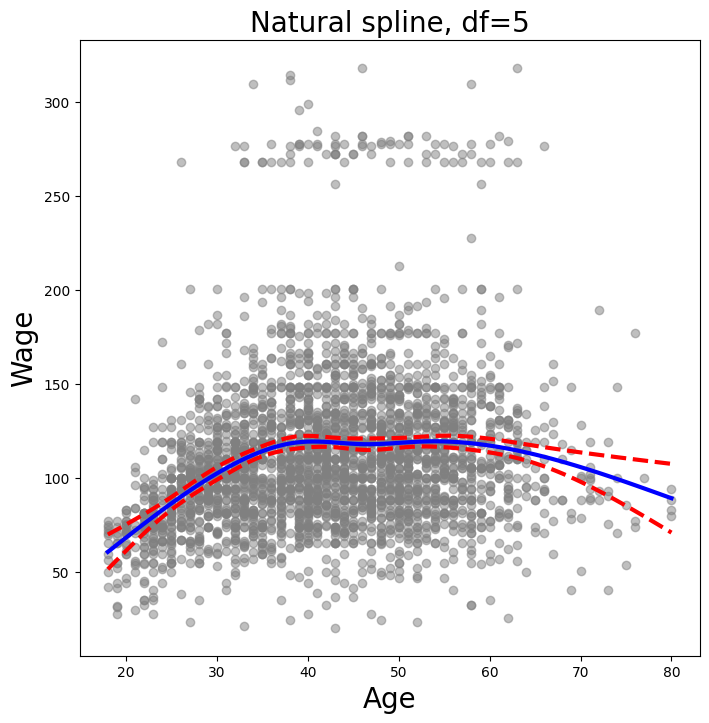

In [84]:
age_grid = np.linspace(age.min(),
                       age.max(),
                       100)
age_df = pd.DataFrame({'age': age_grid})

plot_wage_fit(age_df, ns_age, 'Natural spline, df=5');

**Natural Splines**

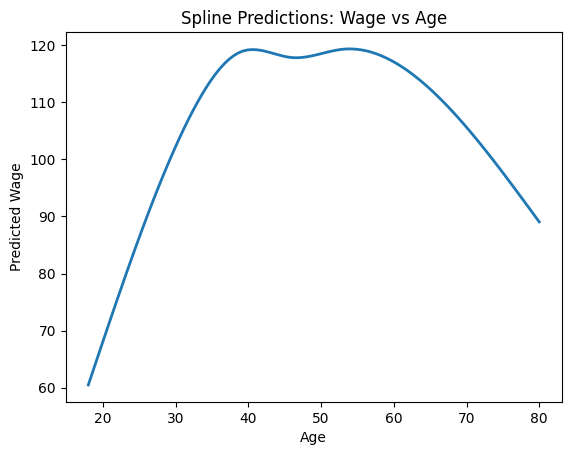

In [86]:
# Recap of the steps:
# 1) Specify X_train and y_train
Wage     = load_data('Wage')
y_train  = Wage['wage']
ns_age   = MS([ns('age', df=5)]).fit(Wage)   # natural spline basis, df=5
X_train  = ns_age.transform(Wage)            # → (n_samples, 5) design matrix

# 2) Create and train the model
model    = sm.OLS(y_train, X_train).fit()

# 3) Make predictions on new ages
age_grid = np.linspace(Wage['age'].min(), Wage['age'].max(), 100)
age_df   = pd.DataFrame({'age': age_grid})
X_new    = ns_age.transform(age_df)          # apply same spline basis
preds     = model.predict(X_new)             # point predictions

plt.plot(age_grid, preds, linewidth=2)
plt.xlabel('Age')
plt.ylabel('Predicted Wage')
plt.title('Spline Predictions: Wage vs Age')
plt.show()

**Smoothing Splines**

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


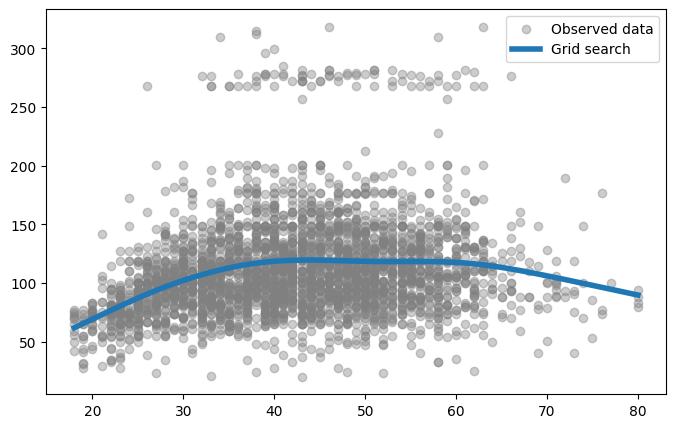

In [95]:
X_age = np.asarray(age).reshape((-1,1))
gam = LinearGAM(s_gam(0, lam=0.6))
gam.fit(X_age, y)

gam_opt = gam.gridsearch(X_age, y)
ax.plot(age_grid,
        gam_opt.predict(age_grid),
        label='Grid search',
        linewidth=4)
ax.legend()
fig

## Lab 6 : Tree Based Methods

**Basic Packages and Lab specific packages** 

In [7]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

In [8]:
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,
export_text)
from sklearn.metrics import (accuracy_score,
log_loss)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART

**Classification Trees**

Traing Error: 0.79
Deviance: 0.4710647062649358
|--- ShelveLoc[Good] <= 0.50
|   |--- Price <= 92.50
|   |   |--- Income <= 57.00
|   |   |   |--- weights: [7.00, 3.00] class: No
|   |   |--- Income >  57.00
|   |   |   |--- weights: [7.00, 29.00] class: Yes
|   |--- Price >  92.50
|   |   |--- Advertising <= 13.50
|   |   |   |--- weights: [183.00, 41.00] class: No
|   |   |--- Advertising >  13.50
|   |   |   |--- weights: [20.00, 25.00] class: Yes
|--- ShelveLoc[Good] >  0.50
|   |--- Price <= 135.00
|   |   |--- US[Yes] <= 0.50
|   |   |   |--- weights: [6.00, 11.00] class: Yes
|   |   |--- US[Yes] >  0.50
|   |   |   |--- weights: [2.00, 49.00] class: Yes
|   |--- Price >  135.00
|   |   |--- Income <= 46.00
|   |   |   |--- weights: [6.00, 0.00] class: No
|   |   |--- Income >  46.00
|   |   |   |--- weights: [5.00, 6.00] class: Yes



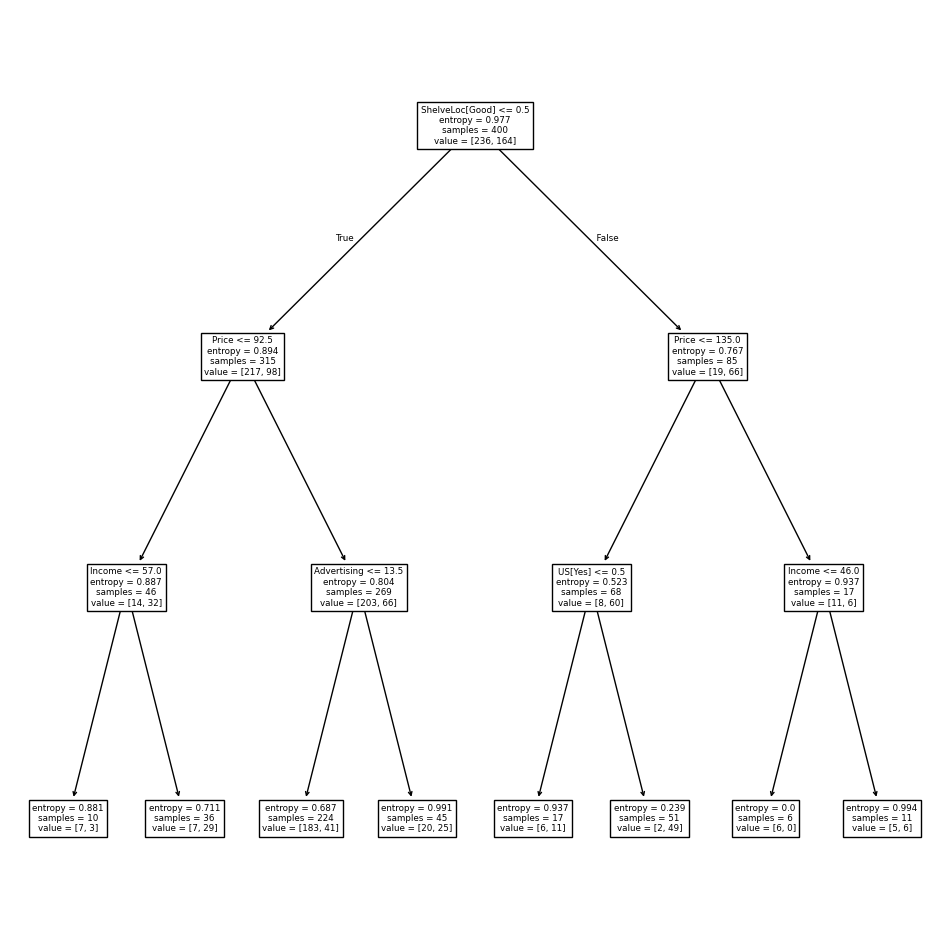

In [ ]:
Carseats = load_data('Carseats')
High = np.where(Carseats.Sales > 8,
                "Yes",
                "No")

model = MS(Carseats.columns.drop('Sales'), intercept=False)
D = model.fit_transform(Carseats)
feature_names = list(D.columns)
X = np.asarray(D)

clf = DTC(criterion='entropy',
          max_depth=3,
          random_state=0)
clf.fit(X, High)

print("Traing Error: " + str(accuracy_score(High, clf.predict(X))))

resid_dev = np.sum(log_loss(High, clf.predict_proba(X)))
print("Deviance: " +str(resid_dev))

ax = subplots(figsize=(12,12))[1]
plot_tree(clf,
          feature_names=feature_names,
          ax=ax);

print(export_text(clf,
                  feature_names=feature_names,
                  show_weights=True))

In [ ]:
#Cross Validation
validation = skm.ShuffleSplit(n_splits=1,
test_size=200,
random_state=0)
results = skm.cross_validate(clf,
D,
High,
cv=validation)
print("Test Score: "+str(results['test_score']))

Test Score: [0.685]


No. of nodes: 30


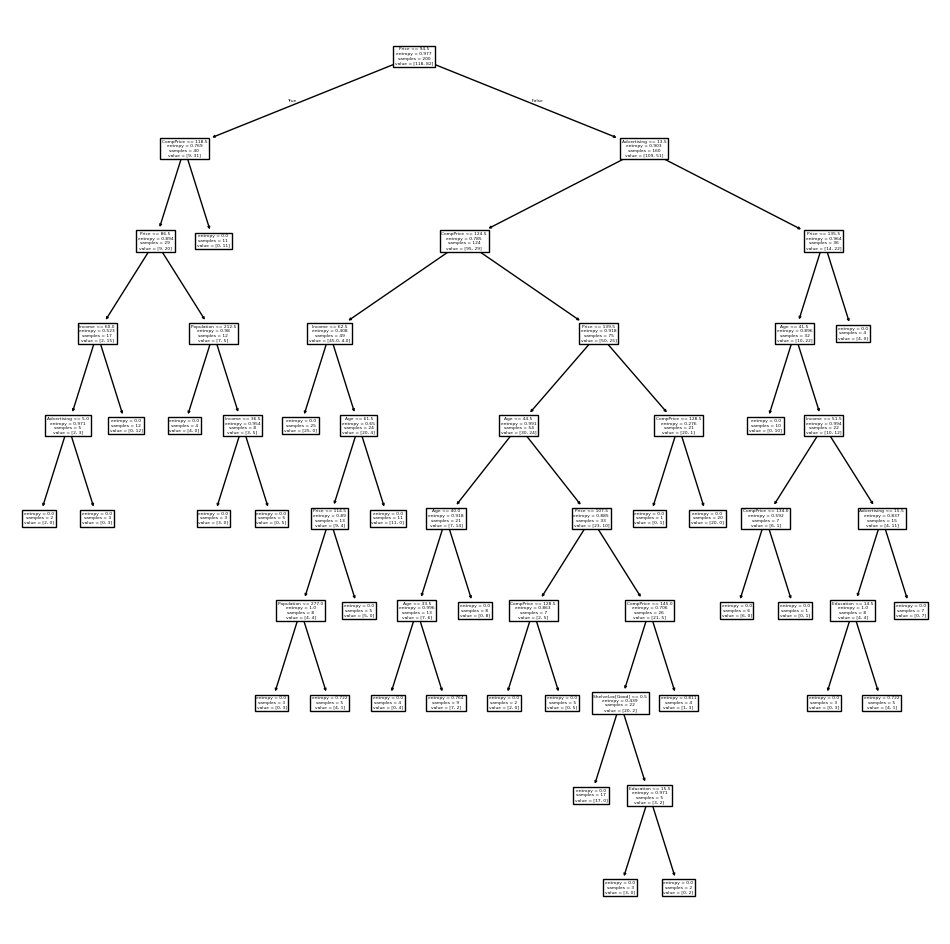

In [ ]:
#Pruning using CV
(X_train,
X_test,
High_train,
High_test) = skm.train_test_split(X,
                                  High,
                                  test_size=0.5,
                                  random_state=0)

clf = DTC(criterion='entropy', random_state=0)
clf.fit(X_train, High_train)
accuracy_score(High_test, clf.predict(X_test))

ccp_path = clf.cost_complexity_pruning_path(X_train, High_train)
kfold = skm.KFold(10,
random_state=1,
shuffle=True)

grid = skm.GridSearchCV(clf,
                         {'ccp_alpha': ccp_path.ccp_alphas},
                         refit=True,
                         cv=kfold,
                         scoring='accuracy')
grid.fit(X_train, High_train)
grid.best_score_

ax = subplots(figsize=(12, 12))[1]
best_ = grid.best_estimator_
plot_tree(best_,
feature_names=feature_names,
ax=ax);

print("No. of nodes: "+str(best_.tree_.n_leaves))

In [ ]:
print("Test Score: "+ str(accuracy_score(High_test,
                                         best_.predict(X_test))))
confusion = confusion_table(best_.predict(X_test),
                            High_test)
confusion

Test Score: 0.72


Truth,No,Yes
Predicted,,
No,94,32
Yes,24,50


**Regression Trees**

In [ ]:
Boston = load_data("Boston")
model = MS(Boston.columns.drop('medv'), intercept=False)
D = model.fit_transform(Boston)
feature_names = list(D.columns)
X = np.asarray(D)

(X_train,
X_test,
y_train,
y_test) = skm.train_test_split(X,
                               Boston['medv'],
                               test_size=0.3,
                               random_state=0)

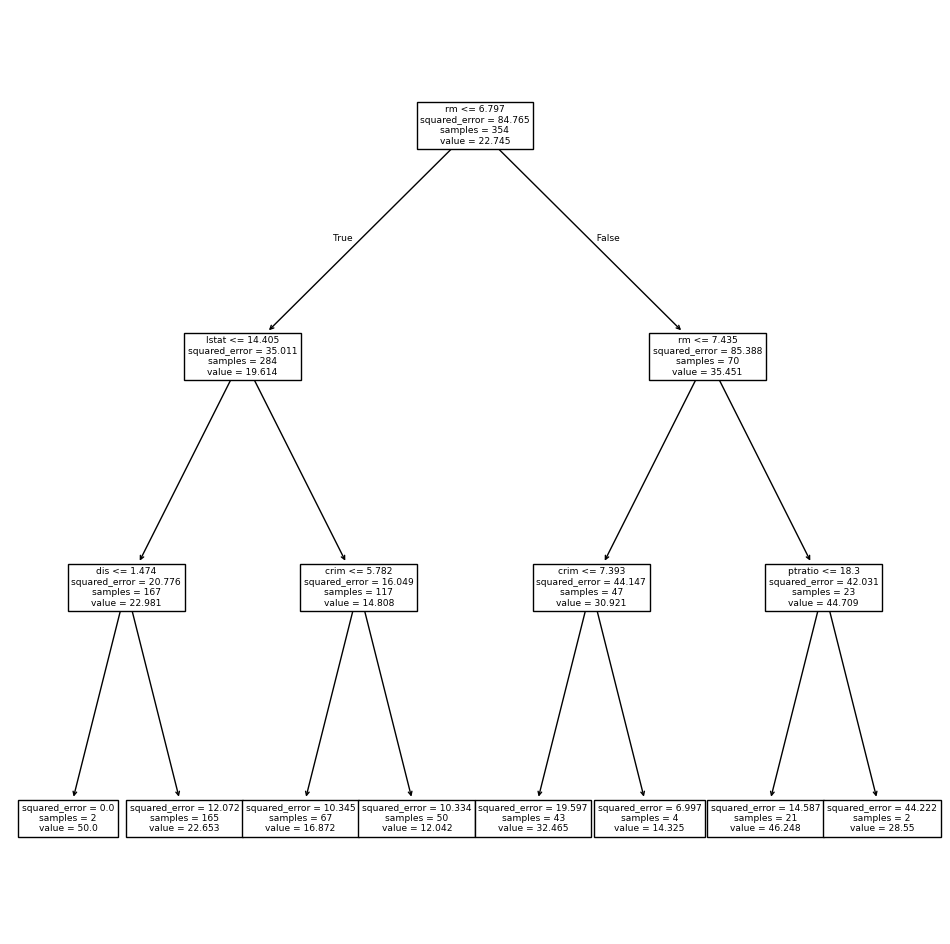

In [ ]:
reg = DTR(max_depth=3)
reg.fit(X_train, y_train)
ax = subplots(figsize=(12,12))[1]
plot_tree(reg,
          feature_names=feature_names,
          ax=ax);

In [ ]:
ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(5,
shuffle=True,
random_state=10)
grid = skm.GridSearchCV(reg,
                        {'ccp_alpha': ccp_path.ccp_alphas},
                        refit=True,
                        cv=kfold,
scoring='neg_mean_squared_error')
G = grid.fit(X_train, y_train)

best_ = grid.best_estimator_
np.mean((y_test - best_.predict(X_test))**2)

28.06985754975404

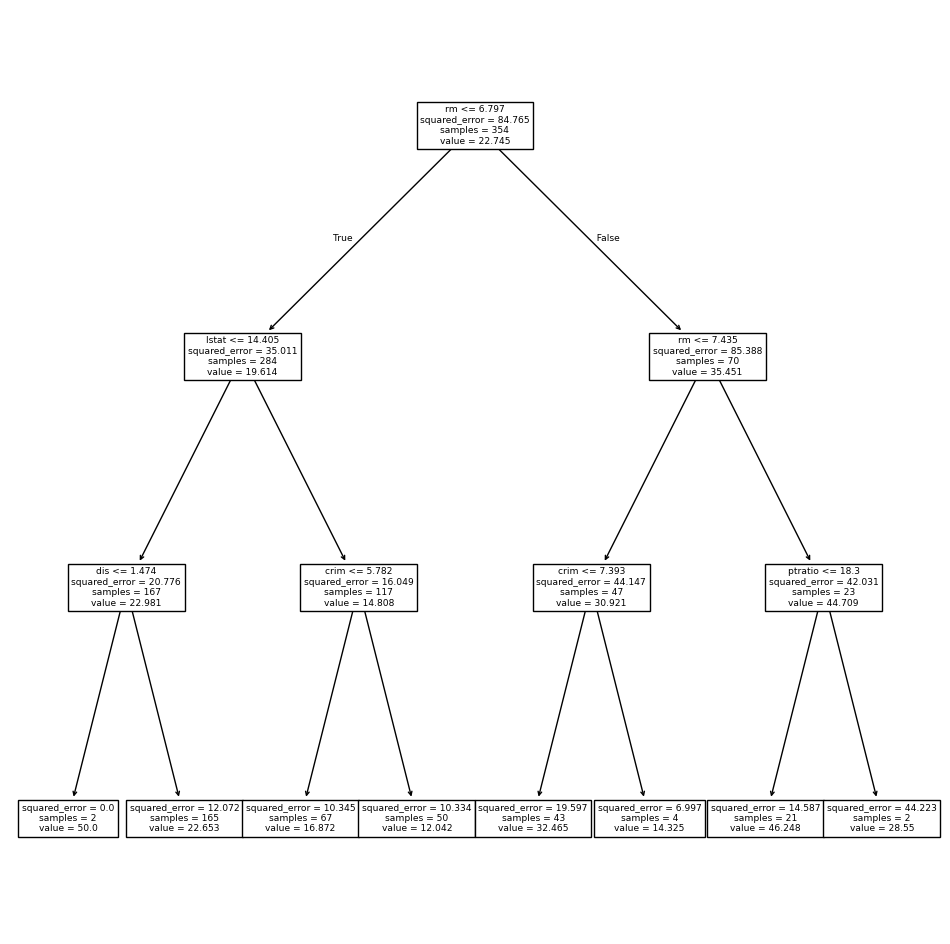

In [ ]:
ax = subplots(figsize=(12,12))[1]
plot_tree(G.best_estimator_,
          feature_names=feature_names,
          ax=ax);

**Bagging, Random Forest, Boosting**

Recall that bagging is a special case of a Random Forest when $m\coloneqq p$

The test set MSE is 14.634700151315787


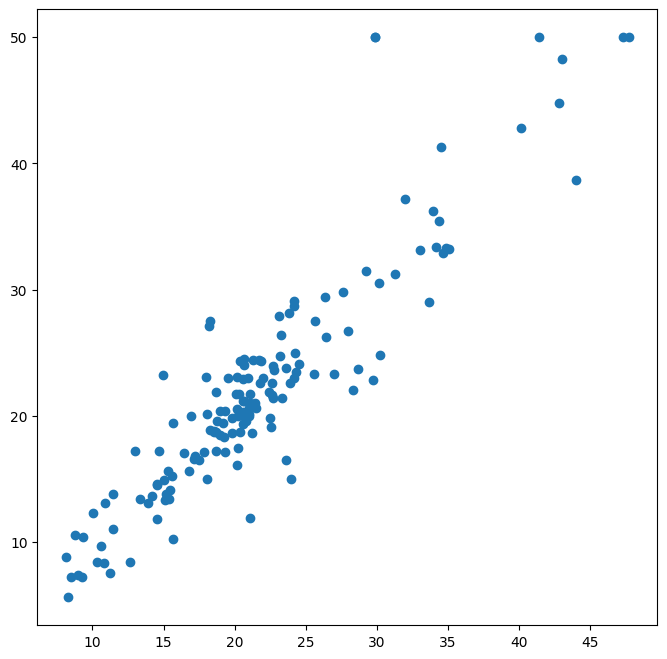

In [ ]:
bag_boston = RF(max_features=X_train.shape[1], random_state=0)
bag_boston.fit(X_train, y_train)

ax = subplots(figsize=(8,8))[1]
y_hat_bag = bag_boston.predict(X_test)
ax.scatter(y_hat_bag, y_test)
print("The test set MSE is "+ str(np.mean((y_test - y_hat_bag)**2)))

In [ ]:
#change the number of trees generated and recalculate the error

bag_boston = RF(max_features=X_train.shape[1],
n_estimators=500,
random_state=0).fit(X_train, y_train)
y_hat_bag = bag_boston.predict(X_test)
print("The new test MSE error is: "+str(np.mean((y_test - y_hat_bag)**2)))

#Using Random Forest (ie limiting the predictors)
RF_boston = RF(max_features=6,
random_state=0).fit(X_train, y_train)
y_hat_RF = RF_boston.predict(X_test)
print("The RF test MSE error is: " + str(np.mean((y_test - y_hat_RF)**2)) + " that indicate a decrease in performance")


The new test MSE error is: 14.605662565263161
The RF test MSE error is: 20.04276446710527 that indicate a decrease in performance


In [ ]:
#For the variable importance:

feature_imp = pd.DataFrame(
{'importance':RF_boston.feature_importances_},
index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
lstat,0.356203
rm,0.332163
ptratio,0.067270
crim,0.055404
indus,0.053851
dis,0.041582
nox,0.035225
tax,0.025355
age,0.021506
rad,0.004784


**Bagging**

Here we use *GradientBoostingRegressor()* from sklearn.ensemble to fit boosted regression trees to the Boston data set.

For classifcation we would use *GradientBoostingClassifier()*.

In [ ]:
boost_boston = GBR(n_estimators=5000,
                   learning_rate=0.001,
                   max_depth=3,
                   random_state=0)
boost_boston.fit(X_train, y_train)

y_hat_boost = boost_boston.predict(X_test);
print("The test MSE error is: " + str(np.mean((y_test - y_hat_boost)**2)))

The test MSE error is: 14.481405918831591


In [ ]:
boost_boston = GBR(n_estimators=5000,
                   learning_rate=0.2,
                   max_depth=3,
                   random_state=0)
boost_boston.fit(X_train,
                 y_train)
y_hat_boost = boost_boston.predict(X_test);
print("The test MSE error is: "+ str(np.mean((y_test - y_hat_boost)**2)))

The test MSE error is: 14.501514553719565


## Unsupervised Learning:

**K-means**

In [20]:
#Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data


# Specific Libraries
from sklearn.cluster import \
    (KMeans ,
     AgglomerativeClustering )
from scipy.cluster.hierarchy import \
    (dendrogram ,
     cut_tree)
from ISLP.cluster import compute_linkage

In [27]:
#Create Data
np.random.seed (0);
X = np.random.standard_normal ((50 ,2));
X[:25 ,0] += 3;
X[:25 ,1] -= 4;

In [ ]:
#K - Means Implementation
kmeans = KMeans(n_clusters =2,
                random_state =2,
                n_init =20).fit(X)

In [23]:
#K - Means Results
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

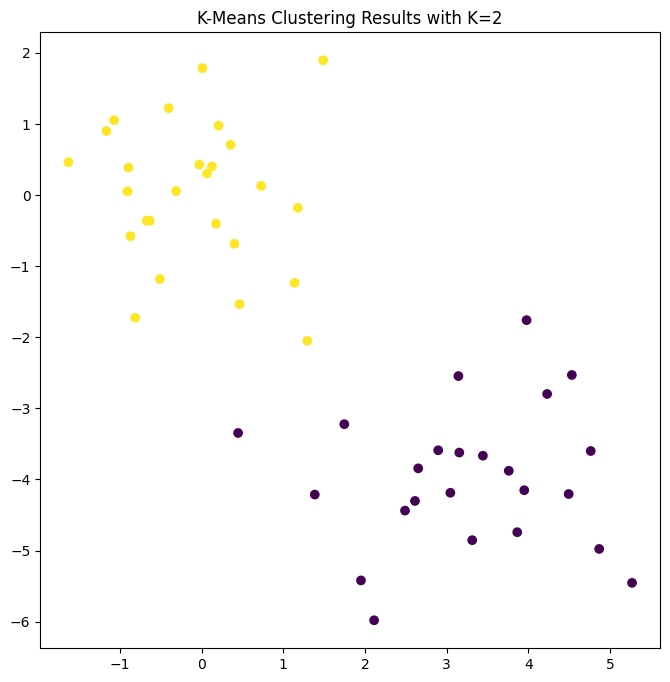

In [24]:
fig , ax = plt.subplots (1, 1, figsize =(8 ,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=2");